# ASX Stock Predictor — Progress Log

## Model Progress

## Project Overview

In [6]:
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd
import numpy as np

In [7]:
conn = sqlite3.connect("asx_stocks.db")
log_display = pd.read_sql("SELECT * FROM progress_log", conn)
log_display["accuracy"] = (log_display["accuracy"] * 100).round(1).astype(str) + "%"

display(log_display.style
    .set_properties(**{"text-align": "left", "font-size": "12px"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#003087"), ("color", "white"), ("font-weight", "bold"), ("padding", "8px")]},
        {"selector": "td", "props": [("padding", "6px 12px"), ("border-bottom", "1px solid #dddddd")]},
        {"selector": "tr:hover", "props": [("background-color", "#f0f4ff")]}
    ])
    .hide(axis="index")
)

version,accuracy,model,notes
v1,48.8%,Random Forest 100 trees,Baseline model
v2,46.9%,Random Forest 100 trees,"Increased data to 10y — accuracy dropped, older data adds noise"
v3,49.2%,Random Forest 150 trees (GridSearchCV),"GridSearchCV tuning, best: 150 trees, test accuracy 49%, tree count has minimal impact"
v4,50.4%,Random Forest 200 trees (GridSearchCV),"Added RSI feature — accuracy improved to 50.4%, RSI ranked among top features, MA30 weakest"
v5,49.2%,Random Forest 125 trees (GridSearchCV),"Removed MA30 — accuracy dropped to 49.2%, MA30 reinstated in v6"
v6,51.2%,Random Forest 400 trees (GridSearchCV),Added Bollinger Bands (BB_Width) — accuracy improved from 49.2% (v5) to 51.2%
v7,50.0%,Random Forest 450 trees (GridSearchCV),"Added MACD — accuracy dropped from 51.2% (v6) to 50%, MACD adds noise"
v8,61.3%,Random Forest 225 trees (GridSearchCV),"DATA LEAKAGE DETECTED — OC_Spread correlation -0.476, inflated accuracy 61%, fix in v9"
v9,50.8%,Random Forest 300 trees (GridSearchCV),"Removed OC_Spread leakage, retained HL_Spread — accuracy restored to 50.8%"
v10,54.0%,Random Forest 250 trees (GridSearchCV),"BEST RESULT — Ascending sort applied — accuracy improved from 50.8% (v9) to 54%, best clean result"


In [10]:
# Import values from SQLite 
conn = sqlite3.connect("asx_stocks.db")
log = pd.read_sql("SELECT * FROM progress_log", conn)
log["version"] = log["version"].astype(str)
print("Database Imported Successfully!")

Database Imported Successfully!


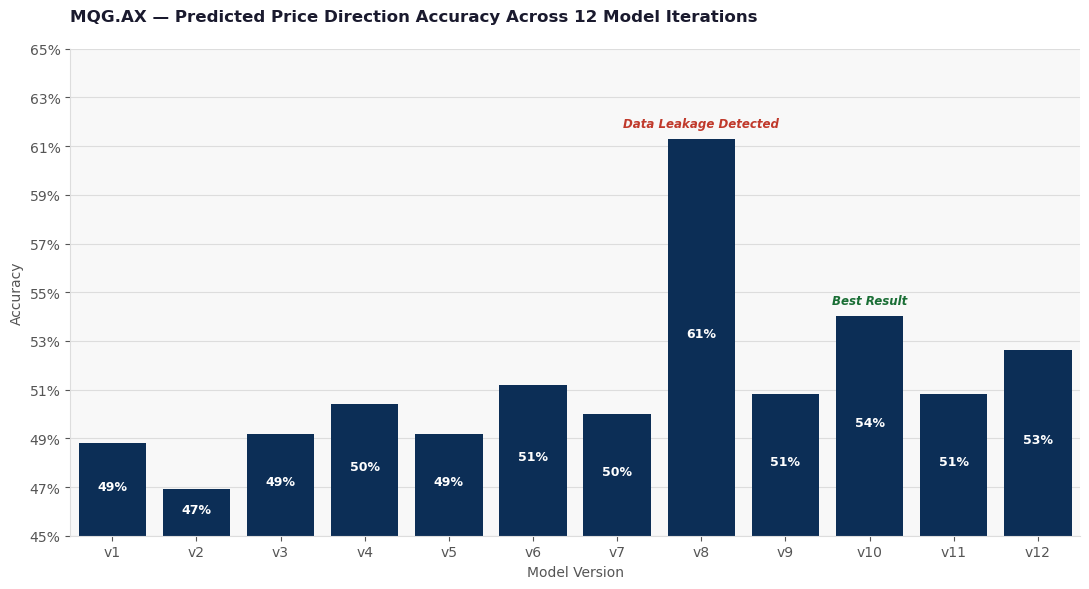

In [11]:
# Create plot
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f8f8")

colours = ["#002D62" for v in log["accuracy"]]
sns.barplot(x=log["version"], y=log["accuracy"], hue=log["version"], palette=colours, edgecolor="none", legend=False, ax=ax)

for i, v in enumerate(log["accuracy"]):
    ax.text(i, v / 2 + 0.225, f"{v:.0%}", ha="center", color="white", fontweight="bold", fontsize=9)

ax.annotate("Data Leakage Detected", xy=(7, 0.618), ha="center", color="#c0392b", fontsize=8.5, fontweight="bold", style="italic")
ax.annotate("Best Result", xy=(9, 0.545), ha="center", color="#1a6e35", fontsize=8.5, fontweight="bold", style="italic")
ax.set_title("MQG.AX — Predicted Price Direction Accuracy Across 12 Model Iterations", 
             fontsize=12, fontweight="bold", pad=20, loc="left", color="#1a1a2e")
ax.set_xlabel("Model Version", fontsize=10, color="#555555")
ax.set_ylabel("Accuracy", fontsize=10, color="#555555")
ax.set_ylim(0.45, 0.65)
ax.set_yticks(np.arange(0.45, 0.66, 0.02))
ax.set_yticklabels([f"{v:.0%}" for v in np.arange(0.45, 0.66, 0.02)], color="#555555")
ax.tick_params(colors="#555555")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#dddddd")
ax.spines["bottom"].set_color("#dddddd")
ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()